In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import os

C:\Users\fzmaj\AppData\Local\Temp\ipykernel_25228\2339457661.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CheckInHour'] = pd.to_datetime(df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_25228\2339457661.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CheckOutHour'] = pd.to_datetime(df['CheckOutTime']).dt.hour


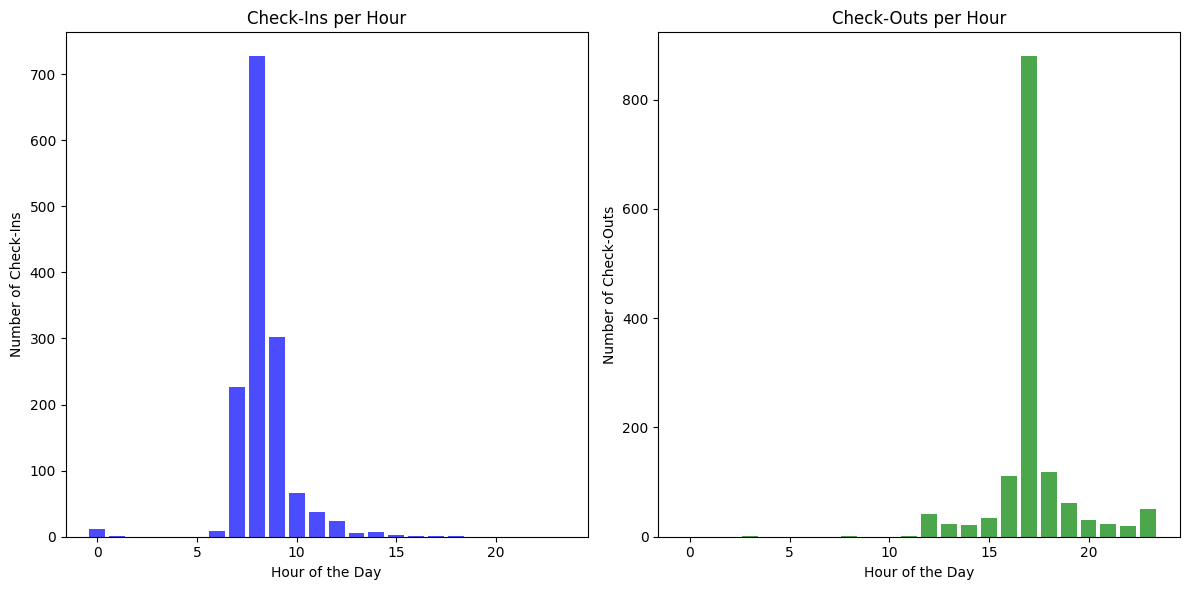

In [7]:

# Load dataset
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3340_giza'))
csv_file = '3340_giza_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df = pd.read_csv(absolute_path)

# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
df['CheckInHour'] = pd.to_datetime(df['CheckInTime']).dt.hour 
df['CheckOutHour'] = pd.to_datetime(df['CheckOutTime']).dt.hour 


# Count check-ins per hour
check_in_counts = df['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = df['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

df['CheckInMinutes'] = df['CheckInTime'].apply(time_to_minutes)
df['CheckOutMinutes'] = df['CheckOutTime'].apply(time_to_minutes)

# Feature engineering: Create features for clustering
features = df[['CheckInMinutes']]    #, 'CheckOutMinutes']].values
features = StandardScaler().fit_transform(features)  # Normalize features

# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k



6
0.521890178460465


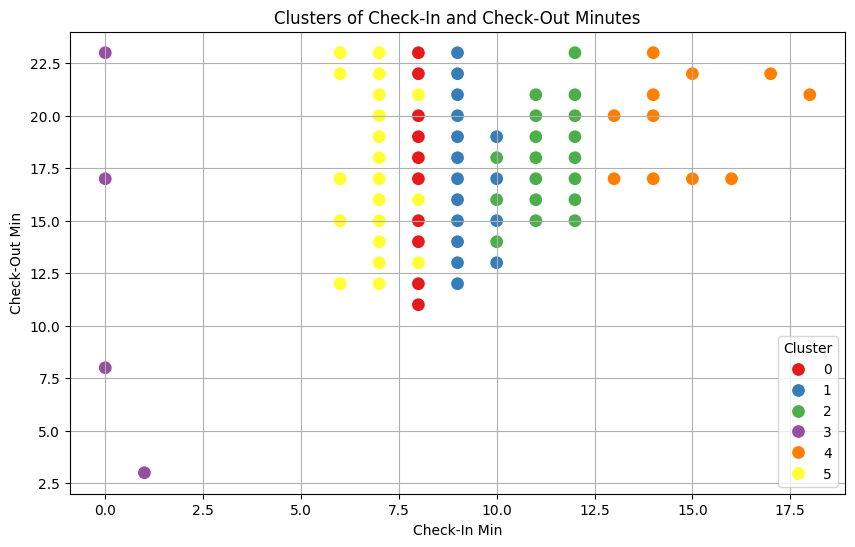

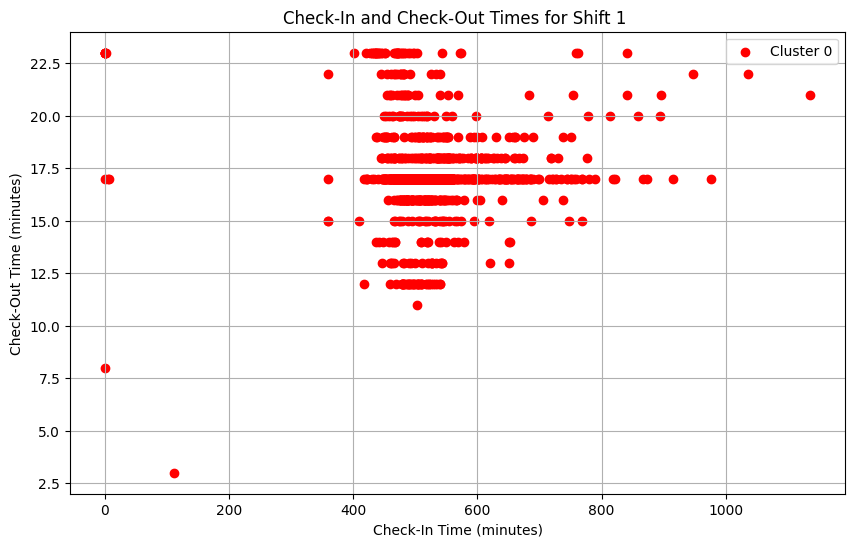

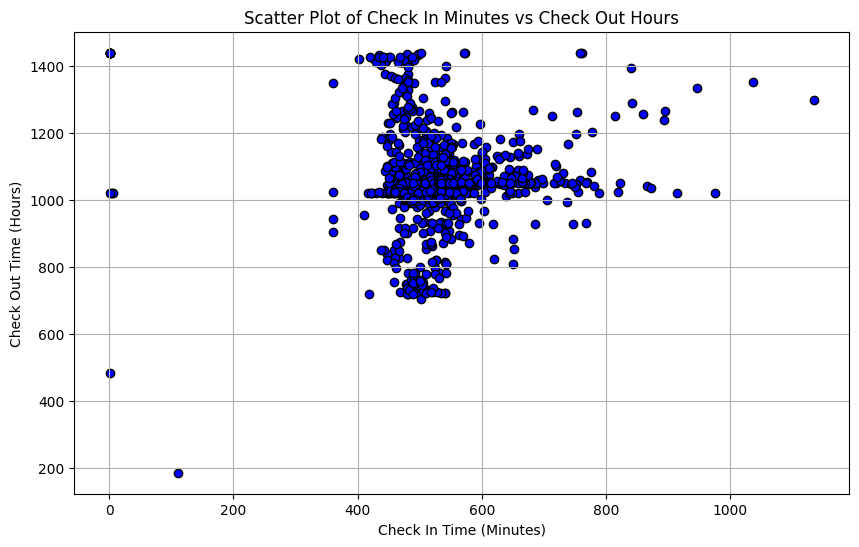

<Figure size 1500x800 with 0 Axes>

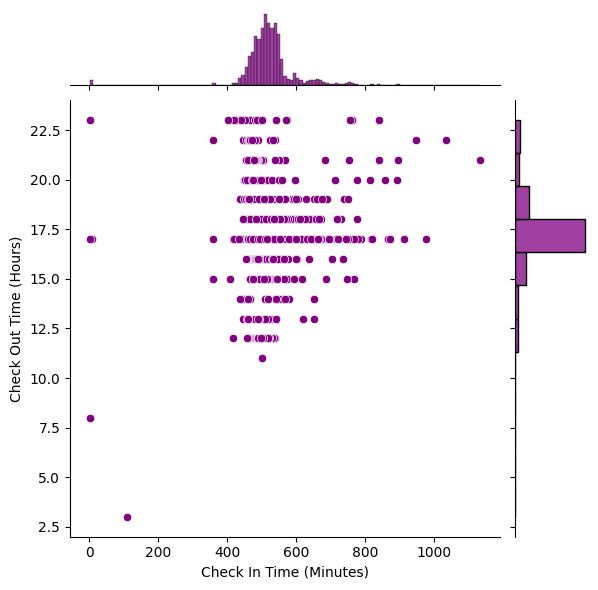

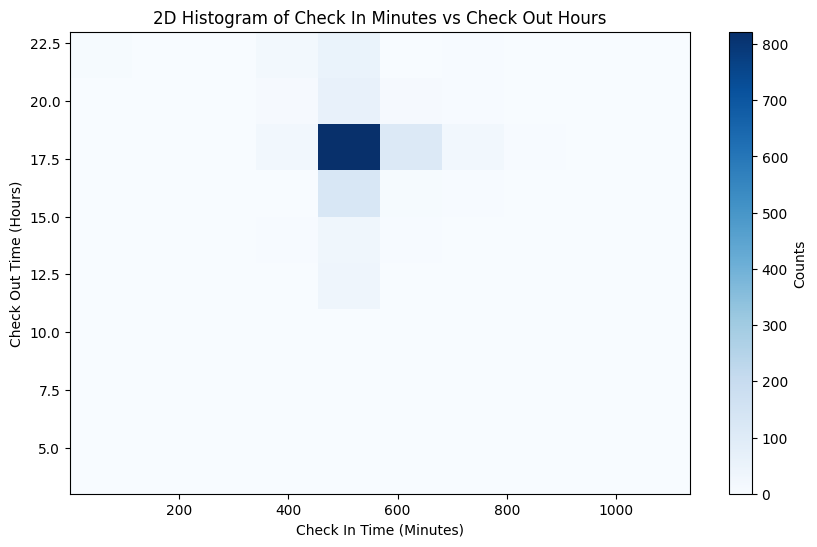

In [9]:
optimal_k = 6 #optimal_k_means(features)
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, df['cluster'])
print(silhouette_avg)
# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInHour', y='CheckOutHour', hue=df['cluster'], data=df, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Minutes')
plt.xlabel('Check-In Min')
plt.ylabel('Check-Out Min')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(df['CheckInMinutes'], df['CheckOutHour'], color='red', label='Cluster 0')
plt.title('Check-In and Check-Out Times for Shift 1 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

# 1. Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['CheckInMinutes'], df['CheckOutMinutes'], color='blue', edgecolor='black')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('Scatter Plot of Check In Minutes vs Check Out Hours')
plt.grid(True)
plt.show()


# 4. Joint Plot (Scatter + Distribution)
plt.figure(figsize=(15, 8))
sns.jointplot(x= df['CheckInMinutes'], y= df['CheckOutHour'], kind='scatter', color='purple')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.show()


# 6. 2D Histogram
plt.figure(figsize=(10, 6))
plt.hist2d(df['CheckInMinutes'], df['CheckOutHour'], bins=10, cmap='Blues')
plt.colorbar(label='Counts')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('2D Histogram of Check In Minutes vs Check Out Hours')
plt.show()

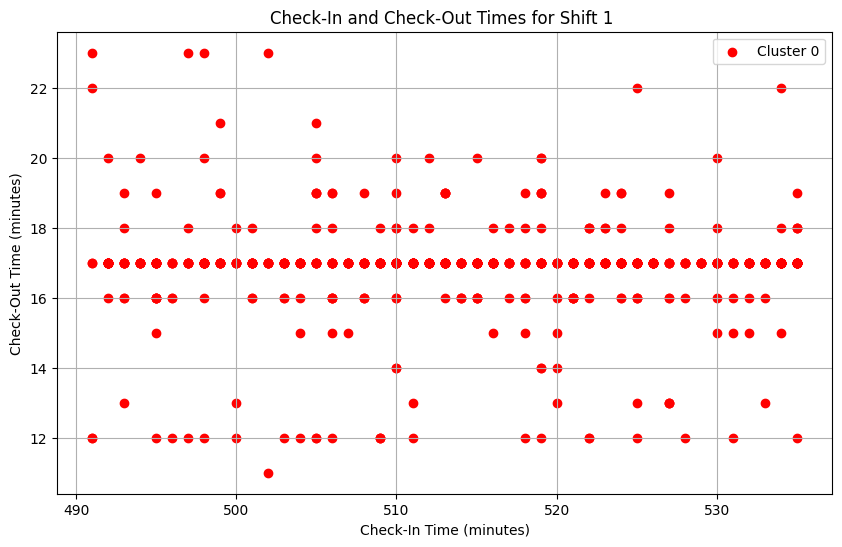

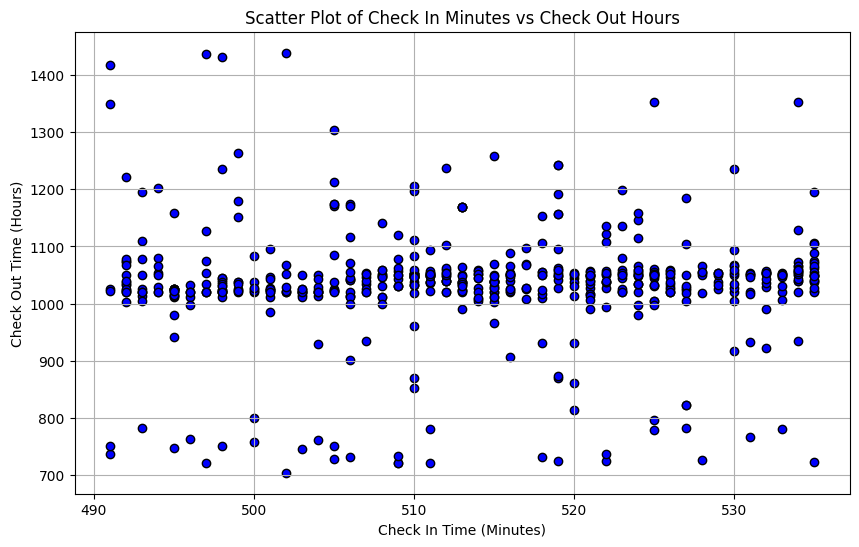

<Figure size 1500x800 with 0 Axes>

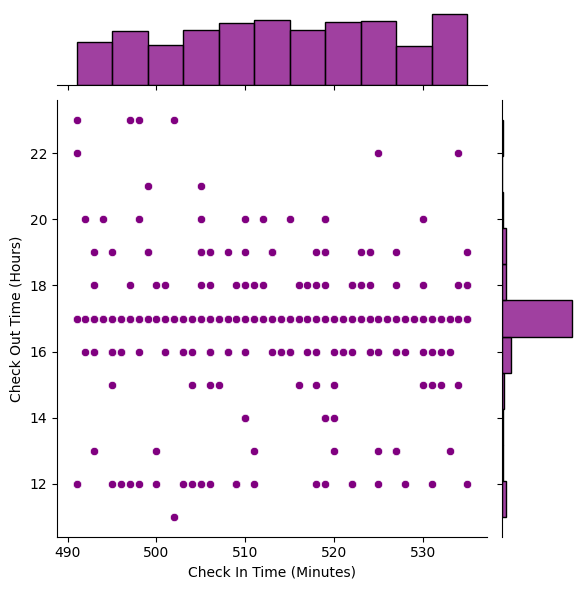

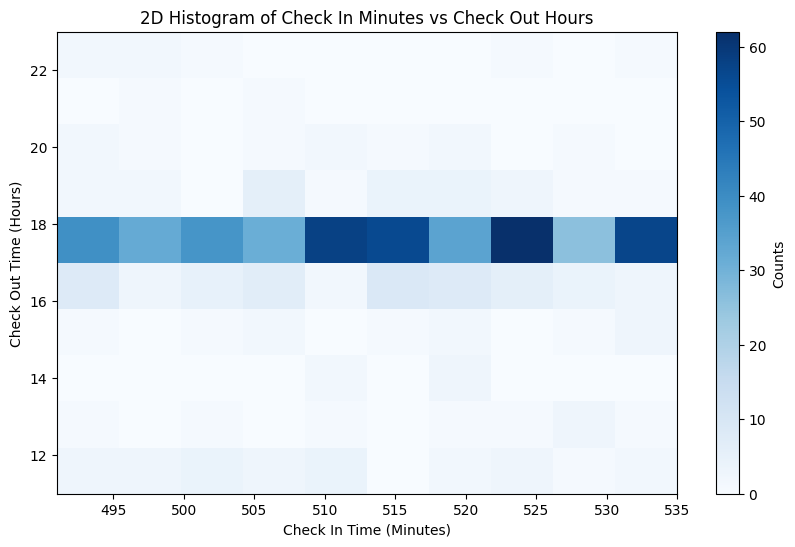

In [10]:
# Filter the DataFrame for Cluster 0
cluster_df = df[df['cluster'] == 0]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutHour'], color='red', label='Cluster 0')
plt.title('Check-In and Check-Out Times for Shift 1 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

# 1. Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInMinutes'], cluster_df['CheckOutMinutes'], color='blue', edgecolor='black')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('Scatter Plot of Check In Minutes vs Check Out Hours')
plt.grid(True)
plt.show()


# 4. Joint Plot (Scatter + Distribution)
plt.figure(figsize=(15, 8))
sns.jointplot(x= cluster_df['CheckInMinutes'], y= cluster_df['CheckOutHour'], kind='scatter', color='purple')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.show()


# 6. 2D Histogram
plt.figure(figsize=(10, 6))
plt.hist2d(cluster_df['CheckInMinutes'], cluster_df['CheckOutHour'], bins=10, cmap='Blues')
plt.colorbar(label='Counts')
plt.xlabel('Check In Time (Minutes)')
plt.ylabel('Check Out Time (Hours)')
plt.title('2D Histogram of Check In Minutes vs Check Out Hours')
plt.show()

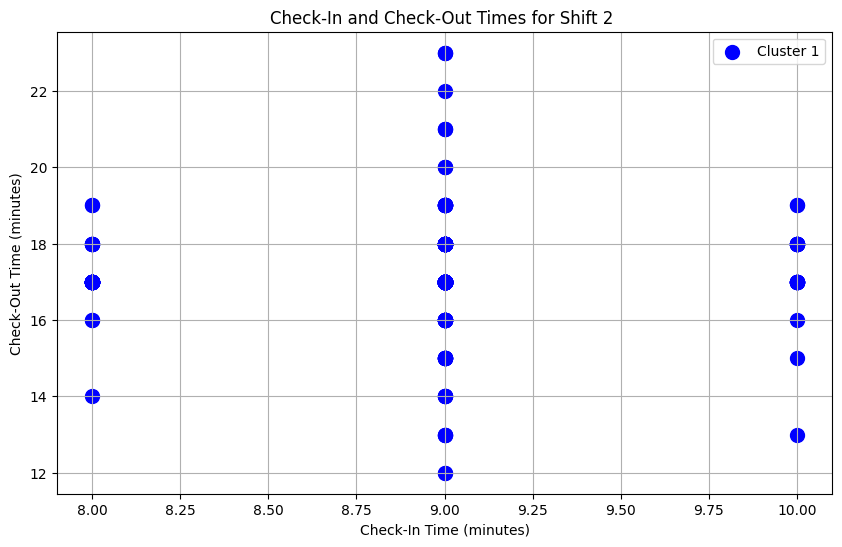

In [11]:
cluster_df = df[df['cluster'] == 1]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='Cluster 1', s=100)
plt.title('Check-In and Check-Out Times for Shift 2 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

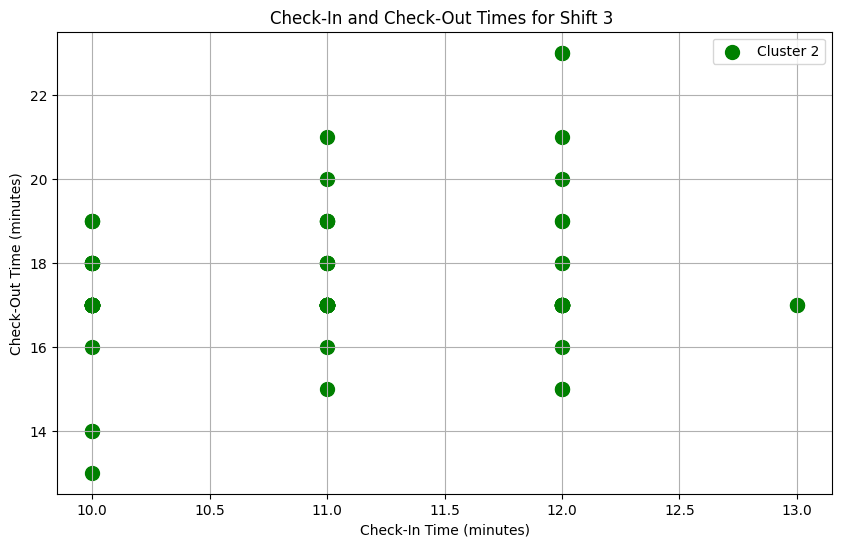

In [12]:
cluster_df = df[df['cluster'] == 2]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='green', label='Cluster 2', s=100)
plt.title('Check-In and Check-Out Times for Shift 3 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

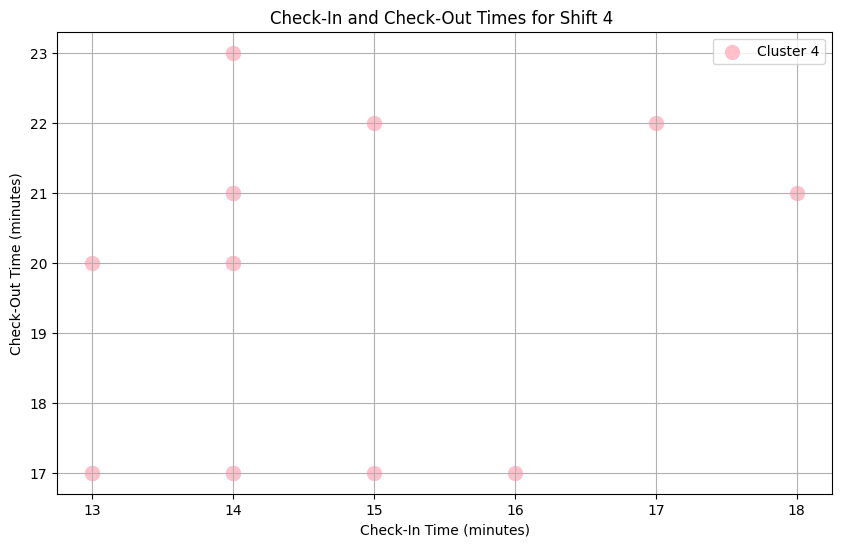

In [13]:
cluster_df = df[df['cluster'] == 4]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='pink', label='Cluster 4', s=100)
plt.title('Check-In and Check-Out Times for Shift 4 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
employee_count_per_cluster = df.groupby('cluster')['EmployeeId'].nunique().reset_index()

# Rename columns for clarity
employee_count_per_cluster.columns = ['cluster', 'NumberOfEmployees']

# Print the result
print(employee_count_per_cluster)

   cluster  NumberOfEmployees
0        0                 41
1        1                 33
2        2                 24
3        3                  4
4        4                  8
5        5                 24


In [15]:

# Calculate start and end hours for each cluster
# Calculate statistics for each cluster
cluster_summary = df.groupby('cluster').agg({
    'CheckInHour': ['mean', 'min', 'max'],
    'CheckOutHour': ['mean', 'min', 'max']
}).reset_index()

# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster', 'CheckInHour_Mean', 'CheckInHour_Min', 'CheckInHour_Max',
                           'CheckOutHour_Mean', 'CheckOutHour_Min', 'CheckOutHour_Max']

# Print the summary
print(cluster_summary)


   Cluster  CheckInHour_Mean  CheckInHour_Min  CheckInHour_Max  \
0        0          8.000000                8                8   
1        1          8.952128                8               10   
2        2         10.900990               10               13   
3        3          0.083333                0                1   
4        4         14.533333               13               18   
5        5          7.275449                6                8   

   CheckOutHour_Mean  CheckOutHour_Min  CheckOutHour_Max  
0          16.824441                11                23  
1          17.111702                12                23  
2          17.386139                13                23  
3          18.583333                 3                23  
4          19.466667                17                23  
5          17.691617                12                23  


Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count
0  2024-10-05 00:00:00     11
1  2024-10-05 01:30:00      1
2  2024-10-05 06:00:00      4
3  2024-10-05 06:30:00      4
4  2024-10-05 07:00:00     40
5  2024-10-05 07:30:00    186
6  2024-10-05 08:00:00    316
7  2024-10-05 08:30:00    411
8  2024-10-05 09:00:00    253
9  2024-10-05 09:30:00     49
10 2024-10-05 10:00:00     33
11 2024-10-05 10:30:00     33
12 2024-10-05 11:00:00     29
13 2024-10-05 11:30:00      8
14 2024-10-05 12:00:00     11
15 2024-10-05 12:30:00     13
16 2024-10-05 13:00:00      2
17 2024-10-05 13:30:00      3
18 2024-10-05 14:00:00      4
19 2024-10-05 14:30:00      3
20 2024-10-05 15:00:00      1
21 2024-10-05 15:30:00      1
22 2024-10-05 16:00:00      1
23 2024-10-05 17:00:00      1
24 2024-10-05 18:30:00      1
3
0.5034623704555043


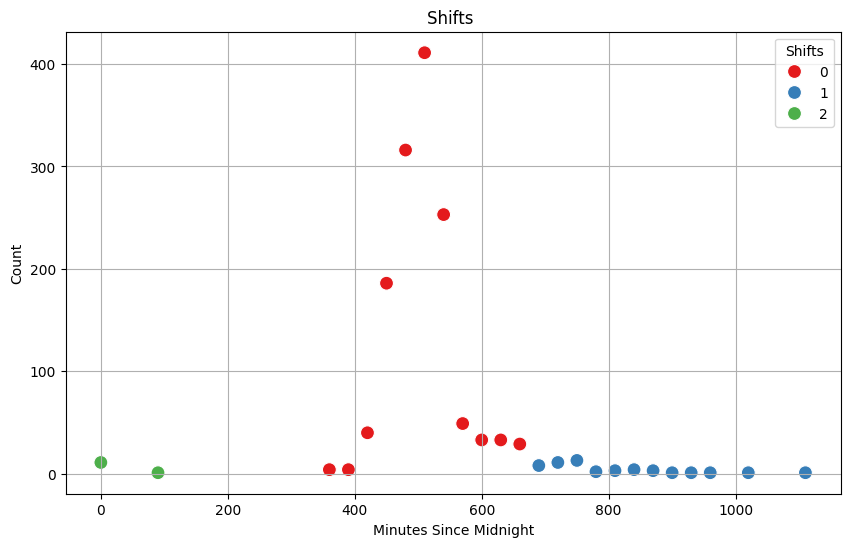

In [16]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
df['CheckInTime'] = pd.to_datetime(df['CheckInTime'], format='%H:%M:%S').dt.time

def round_to_nearest_30_minutes(time):
    # Convert time to minutes, round to nearest 30, then convert back to time
    minute = (time.minute // 30) * 30
    return time.replace(minute=minute, second=0, microsecond=0)

# Apply rounding function
df['RoundedCheckInTime'] = df['CheckInTime'].apply(lambda x: round_to_nearest_30_minutes(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts = df['RoundedCheckInTime'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df = attendance_counts.reset_index()
attendance_df.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
print(attendance_df)

# Convert TimeInterval to numerical feature (e.g., minutes since midnight)
def time_to_minutes(time_obj):
    # Ensure the time_obj is in proper format (HH:MM)
    if isinstance(time_obj, pd.Timestamp):
        hours, minutes = time_obj.hour, time_obj.minute
    else:
        hours, minutes = map(int, str(time_obj).split(':'))
    return hours * 60 + minutes

attendance_df['MinutesSinceMidnight'] = attendance_df['TimeInterval'].apply(time_to_minutes)

# Features for clustering
features = attendance_df[['MinutesSinceMidnight', 'Count']]

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k

optimal_k = optimal_k_means(scaled_features)
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
attendance_df['Shifts'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, attendance_df['Shifts'])
print(silhouette_avg)
# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MinutesSinceMidnight', y='Count', hue=attendance_df['Shifts'], data=attendance_df, palette='Set1', s=100)
plt.title('Shifts ')
plt.xlabel('Minutes Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  HoursSinceMidnight
0  2024-10-05 00:00:00     11                   0
1  2024-10-05 01:00:00      1                   1
2  2024-10-05 06:00:00      8                   6
3  2024-10-05 07:00:00    226                   7
4  2024-10-05 08:00:00    727                   8
5  2024-10-05 09:00:00    302                   9
6  2024-10-05 10:00:00     66                  10
7  2024-10-05 11:00:00     37                  11
8  2024-10-05 12:00:00     24                  12
9  2024-10-05 13:00:00      5                  13
10 2024-10-05 14:00:00      7                  14
11 2024-10-05 15:00:00      2                  15
12 2024-10-05 16:00:00      1                  16
13 2024-10-05 17:00:00      1                  17
14 2024-10-05 18:00:00      1                  18
8
0.3660203580717163


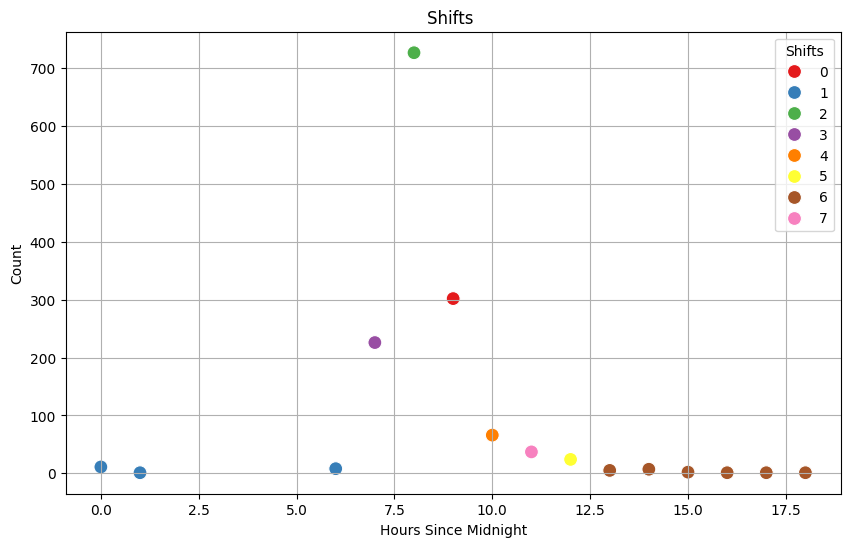

In [17]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
df['CheckInTime'] = pd.to_datetime(df['CheckInTime'], format='%H:%M:%S').dt.time

# Function to round times to the nearest hour
def round_to_nearest_hour(time):
    hour = time.hour
    return time.replace(minute=0, second=0, microsecond=0)

# Apply rounding function
df['RoundedCheckInTime_H'] = df['CheckInTime'].apply(lambda x: round_to_nearest_hour(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts_H = df['RoundedCheckInTime_H'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df_H = attendance_counts_H.reset_index()
attendance_df_H.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)
# Convert TimeInterval to numerical feature (e.g., hours since midnight)
def time_to_hours(time_obj):
    return time_obj.hour

attendance_df_H['HoursSinceMidnight'] = attendance_df_H['TimeInterval'].apply(time_to_hours)

print(attendance_df_H)


# Features for clustering
features = attendance_df_H[['HoursSinceMidnight', 'Count']]

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k

#optimal_k = optimal_k_means(scaled_features)
optimal_k = 8
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
attendance_df_H['Shifts'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, attendance_df_H['Shifts'])
print(silhouette_avg)
# Plot 

plt.figure(figsize=(10, 6))
sns.scatterplot(x='HoursSinceMidnight', y='Count', hue=attendance_df_H['Shifts'], data=attendance_df_H, palette='Set1', s=100)
plt.title('Shifts ')
plt.xlabel('Hours Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()

# Save the data to CSV file and Ensure directory exists
output_dir = '../../data/processed/3340_giza'
os.makedirs(output_dir, exist_ok=True)
attendance_df_H.to_csv(os.path.join(output_dir, 'Attendance.csv'), index=False)



In [18]:
%pip install pandas numpy matplotlib scipy



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


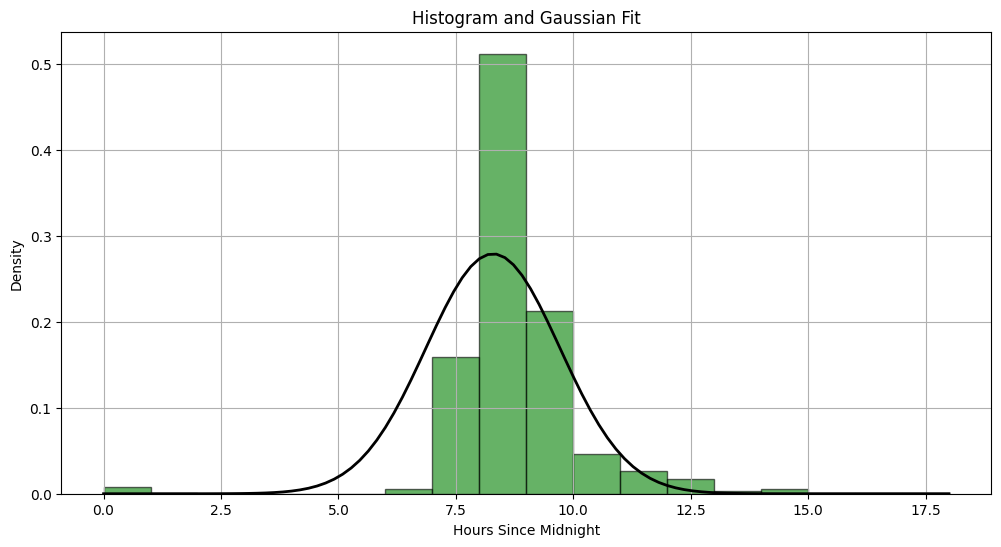

In [19]:
from scipy.stats import norm

expanded_data = []
for _, row in attendance_df_H.iterrows():
    expanded_data.extend([row['HoursSinceMidnight']] * row['Count'])

expanded_data = np.array(expanded_data)

# Fit Gaussian distribution
mu, std = norm.fit(expanded_data)

# Create a range of values for plotting the Gaussian distribution
xmin, xmax = expanded_data.min(), expanded_data.max()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot histogram and Gaussian fit
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data, bins=range(int(xmin), int(xmax) + 1), density=True, alpha=0.6, color='g', edgecolor='black')

# Plot Gaussian distribution
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit')
plt.grid(True)
plt.show()

Variance: 2.039730606621801


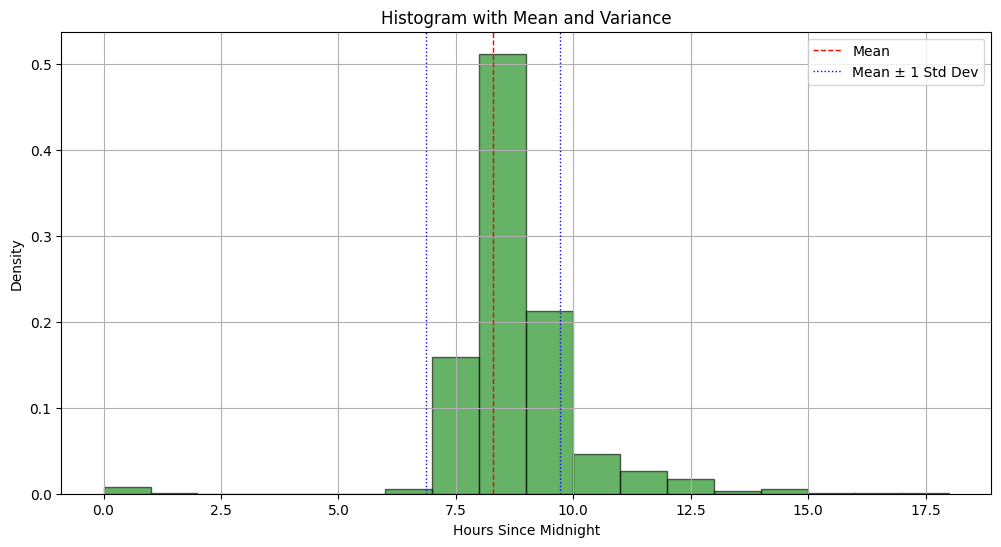

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
expanded_data = []
for _, row in attendance_df_H.iterrows():
    expanded_data.extend([row['HoursSinceMidnight']] * row['Count'])

expanded_data = np.array(expanded_data)

# Compute mean and variance
mean = np.mean(expanded_data)
variance = np.var(expanded_data, ddof=0)  # Population variance
std_dev = np.sqrt(variance)


print(f"Variance: {variance}")

# Plot histogram
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data, bins=range(int(expanded_data.min()), int(expanded_data.max()) + 1), density=True, alpha=0.6, color='g', edgecolor='black')

# Plot mean
plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label='Mean')

# Plot variance (standard deviation)
plt.axvline(mean + std_dev, color='b', linestyle='dotted', linewidth=1, label='Mean ± 1 Std Dev')
plt.axvline(mean - std_dev, color='b', linestyle='dotted', linewidth=1)

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram with Mean and Variance')
plt.legend()
plt.grid(True)
plt.show()


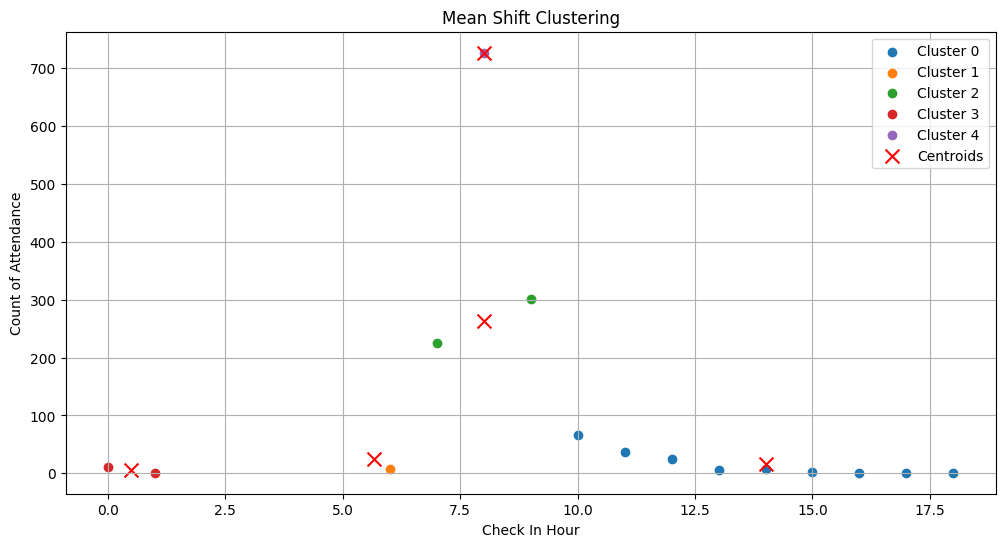

Cluster Centers:
   HoursSinceMidnight  Count
0           14.000000   16.0
1            5.666667   25.0
2            8.000000  264.0
3            0.500000    6.0
4            8.000000  727.0
Cluster Centers (not exact, due to random labels):
               TimeInterval  Count  HoursSinceMidnight    Shifts
Cluster                                                         
0       2024-10-05 14:00:00   16.0                14.0  5.777778
1       2024-10-05 06:00:00    8.0                 6.0  1.000000
2       2024-10-05 08:00:00  264.0                 8.0  1.500000
3       2024-10-05 00:30:00    6.0                 0.5  1.000000
4       2024-10-05 08:00:00  727.0                 8.0  2.000000


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import MeanShift
from sklearn.metrics import pairwise_distances_argmin_min

# Features for neural network
features = attendance_df_H[['HoursSinceMidnight', 'Count']]

# Normalize features
# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply Mean Shift clustering
mean_shift = MeanShift()
clusters = mean_shift.fit_predict(scaled_features)

# Add cluster labels to the original DataFrame
attendance_df_H['Cluster'] = clusters

# Plot results
plt.figure(figsize=(12, 6))
for i in np.unique(clusters):
    cluster_data = attendance_df_H[attendance_df_H['Cluster'] == i]
    plt.scatter(cluster_data['HoursSinceMidnight'], cluster_data['Count'], label=f'Cluster {i}')

# Plot cluster centers (if needed)
cluster_centers = mean_shift.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers)
plt.scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1], c='red', marker='x', s=100, label='Centroids')

plt.xlabel('Check In Hour')
plt.ylabel('Count of Attendance')
plt.title('Mean Shift Clustering')
plt.legend()
plt.grid(True)
plt.show()

# Print cluster centers
print("Cluster Centers:")
print(pd.DataFrame(cluster_centers_original, columns=['HoursSinceMidnight', 'Count']))

# Print cluster centers
print("Cluster Centers (not exact, due to random labels):")
print(attendance_df_H.groupby('Cluster').mean())
